In [1]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

Computing stall boundary...
W/S: 91.991 lb/ft^2
Stall coefficient: 0.000021


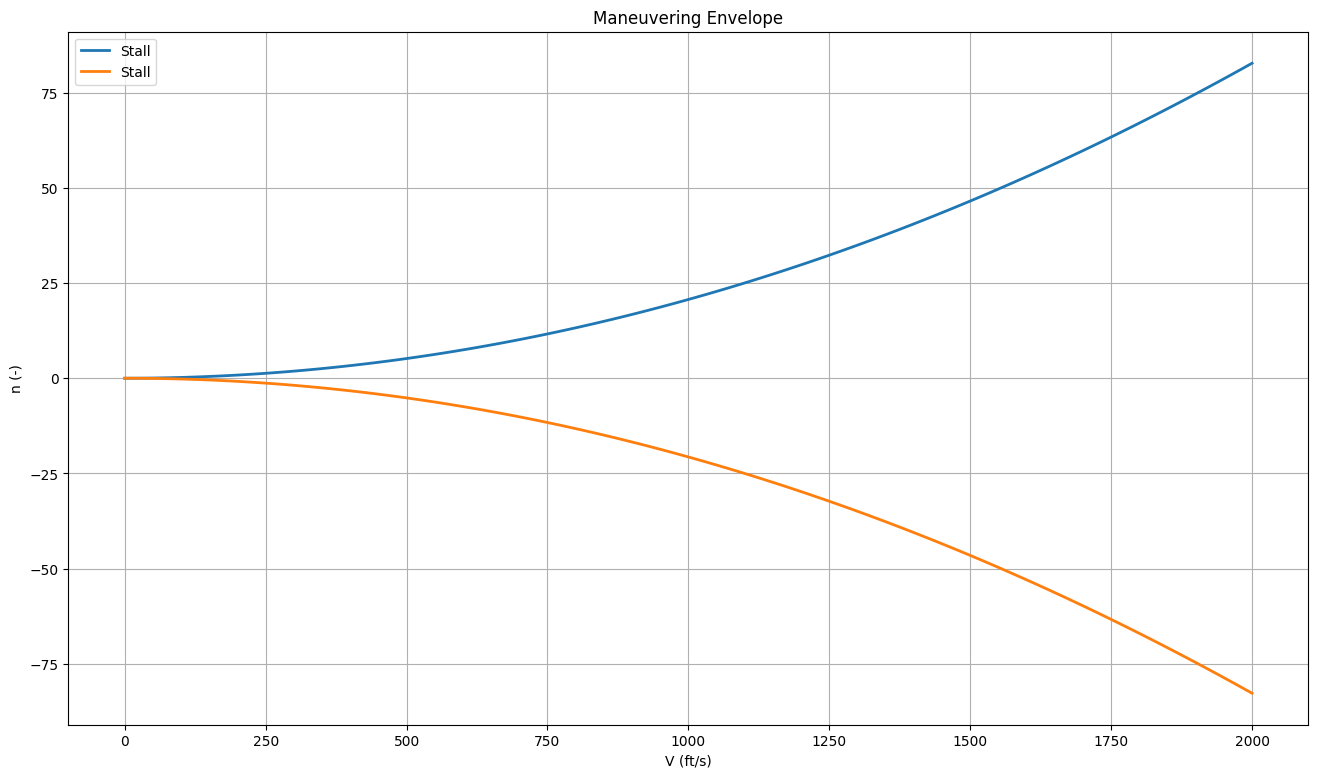

In [ ]:
def compute_stall_boundary(V_min, V_max, n_points, rho, CL_max, Weight, S_ref):
    print("Computing stall boundary...")
    stall_coeff = 0.5 * rho * CL_max / (Weight / S_ref)
    print(f"W/S: {Weight / S_ref:.3f} lb/ft^2")
    print(f"Stall coefficient: {stall_coeff:.6f}")

    V = np.linspace(V_min, V_max, n_points)
    n_Stall = stall_coeff * V**2

    return V, n_Stall, stall_coeff


V_min = 0            # ft/s
V_max = 2000   # ft/s determined from goal mach 2.0 at 30,000 ft (representing TAS not EAS)
n_points = 100

rho = 0.002377       # slugs/ft^3 (sea level)
CL_max = 1.6

MTOW_lb = 36796.33     # [set to 0 if doing min case] change for mission type (strike=36796.33) (a2a=33953.47)
minTOW_lb = 0          # [set to 0 if doing max case] change for mission type (strike=22489.32) (a2a=22404.03)
Weight = MTOW_lb + minTOW_lb    # lbf
S_ref = 400   # ft^2 

# --- RUN ---
Boundary_V, Boundary_n_Stall, stall_coeff = compute_stall_boundary(
    V_min, V_max, n_points, rho, CL_max, Weight, S_ref
)

V = np.linspace(V_min, V_max, n_points)

# --- PLOT ---
plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope')
plt.xlabel("V (ft/s)")
plt.ylabel("n (-)")
plt.plot(Boundary_V, Boundary_n_Stall, label='Stall', linewidth=2)
plt.plot(Boundary_V, -Boundary_n_Stall, label='Stall', linewidth=2)
plt.grid(True)
plt.legend(loc='best')
plt.show()

Negative limit load factor: -2.80


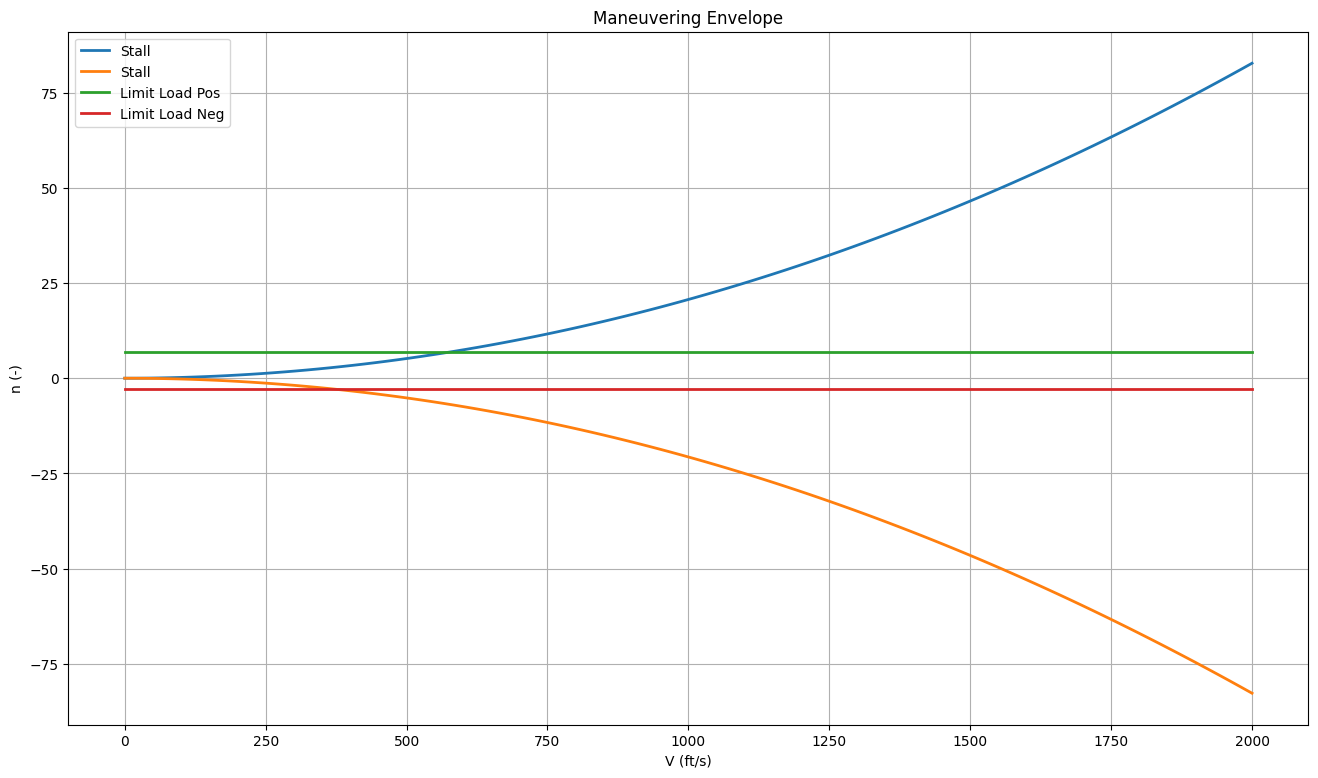

In [5]:
def compute_positive_limit_loads(weight_lb):
    n_pos_formula = 2.1 + 24000 / (weight_lb + 10000)  # FAR 25.337 formula

    if n_pos_formula < 2.5:
        print(f"Computed positive limit load factor is {n_pos_formula:.2f}, "
              f"so use 2.50 based on FAR 25 minimum.")
        selected_n_pos_limit = 2.5
    elif n_pos_formula > 3.8:
        print(f"Computed positive limit load factor is {n_pos_formula:.2f}, "
              f"so cap at 3.80 based on FAR 25 maximum.")
        selected_n_pos_limit = 3.8
    else:
        print(f"Computed positive limit load factor is {n_pos_formula:.2f}, "
              f"so use the computed value.")
        selected_n_pos_limit = n_pos_formula

    return selected_n_pos_limit

MTOW_lb = 36796.33 # lb, maximum takeoff weight; change for mission type (strike=36796.33) (a2a=33953.47)
# n_pos_limit = compute_positive_limit_loads(MTOW_lb)   #can ignore this unless we find a formula for fighter jet max turning load factor
n_pos_limit = 7   # set to 7 or 8g according to goal
n_pos_limit = np.ones(100)*n_pos_limit

# Under MIL-A-8861, the negative limit load factor is generally specified as:
n_neg_limit = -0.4 * n_pos_limit * np.ones(100)
print(f"Negative limit load factor: {n_neg_limit[0]:.2f}")

plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope')
plt.xlabel("V (ft/s)")
plt.ylabel("n (-)")
plt.plot(Boundary_V, Boundary_n_Stall, label='Stall', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.plot(Boundary_V, -Boundary_n_Stall, label='Stall', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.plot(V,n_pos_limit, label='Limit Load Pos', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.plot(V,n_neg_limit, label='Limit Load Neg', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.grid(True)
plt.legend(loc='best')
plt.show()

Intersection velocity for n_limit=7.00 is 581.92 m/s
Intersection velocity for n_limit=-2.80 is 368.04 m/s


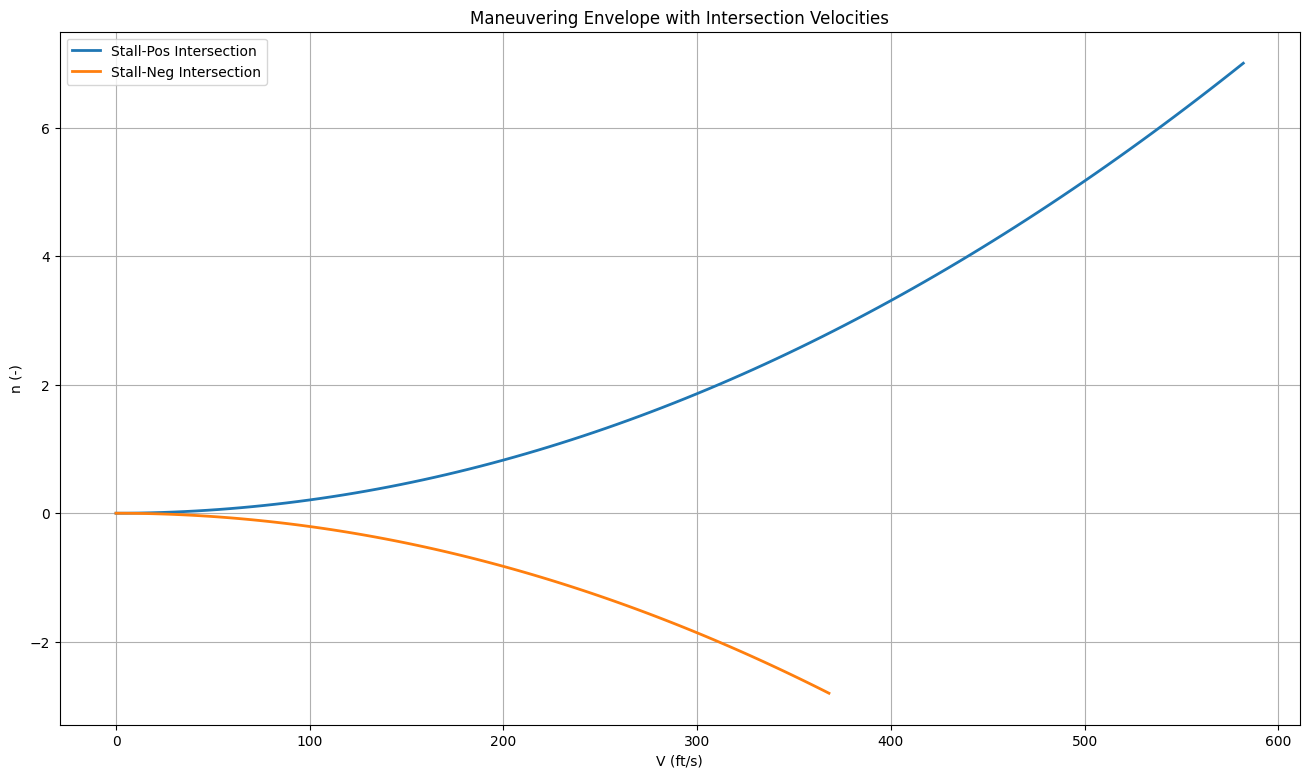

In [6]:
def compute_intersection_velocity(stall_coeff, n_limit):
    """
    Solve stall_coeff * V^2 = |n_limit|
    """
    int_V = np.sqrt(abs(n_limit) / stall_coeff)
    print(f"Intersection velocity for n_limit={n_limit:.2f} is {int_V:.2f} m/s")
    return int_V

# Compute intersection velocities for positive and negative limit load factors with in the stall boundary
V_stall_pos_end = compute_intersection_velocity(stall_coeff, n_pos_limit[0])
V_stall_pos = np.linspace(0, V_stall_pos_end, 100)

V_stall_neg_end = compute_intersection_velocity(stall_coeff, n_neg_limit[0])
V_stall_neg = np.linspace(0, V_stall_neg_end, 100)

# Compute the corresponding n values at the intersection points
n_stall_pos_intersection = stall_coeff * V_stall_pos**2
n_stall_neg_intersection = -stall_coeff * V_stall_neg**2

plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope with Intersection Velocities')
plt.xlabel("V (ft/s)")
plt.ylabel("n (-)")
plt.plot(V_stall_pos, n_stall_pos_intersection  , label='Stall-Pos Intersection', linewidth=2, marker=None, markersize=8)
plt.plot(V_stall_neg, n_stall_neg_intersection  , label='Stall-Neg Intersection', linewidth=2, marker=None, markersize=8)
plt.grid(True)
plt.legend(loc='best')
plt.show()


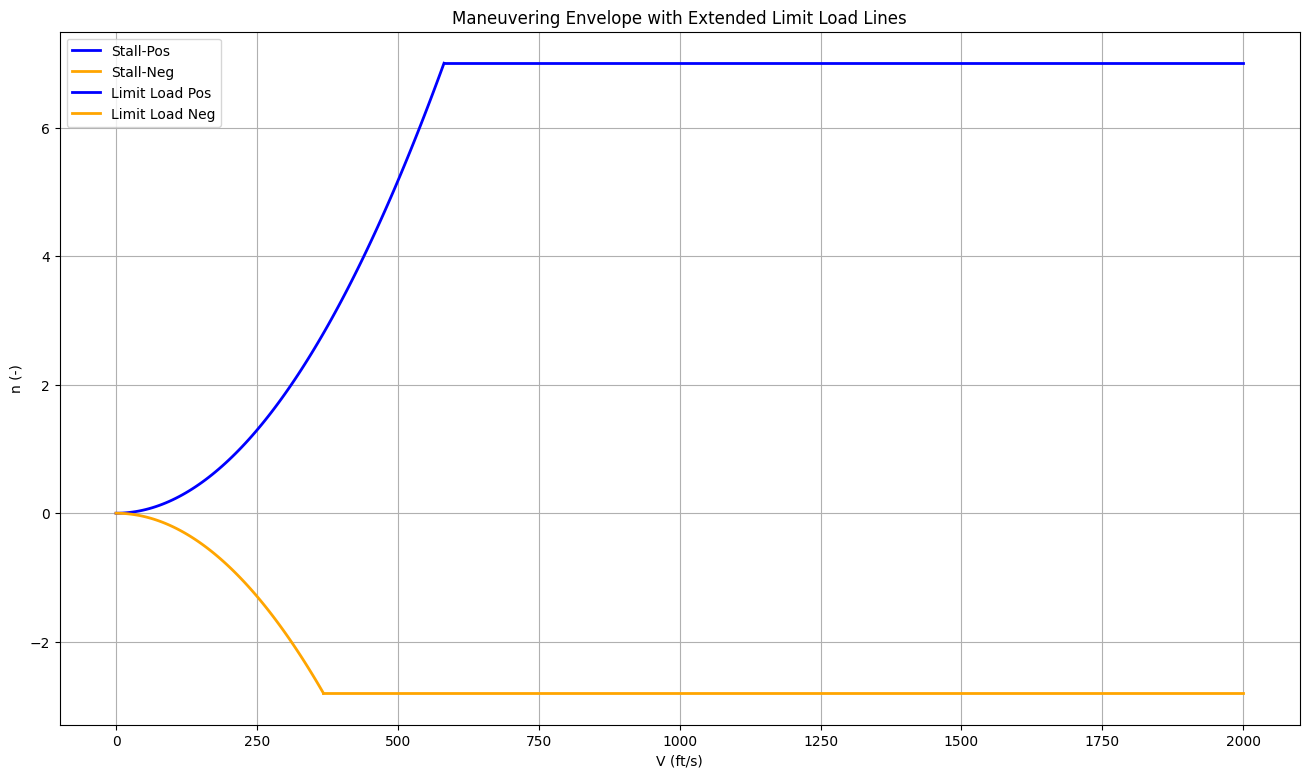

In [7]:
# Extend the positive limit load line to the right of the intersection point
V_pos_limit_extended = np.linspace(V_stall_pos_end, V_max, 100)
V_neg_limit_extended = np.linspace(V_stall_neg_end, V_max, 100)
n_pos_extended = n_pos_limit[0] * np.ones_like(V_pos_limit_extended)
n_neg_extended = n_neg_limit[0] * np.ones_like(V_neg_limit_extended)

plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope with Extended Limit Load Lines')
plt.xlabel("V (ft/s)")
plt.ylabel("n (-)")
plt.plot(V_stall_pos, n_stall_pos_intersection  , label='Stall-Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_stall_neg, n_stall_neg_intersection  , label='Stall-Neg', linewidth=2, marker=None, markersize=8, color ='orange')
plt.plot(V_pos_limit_extended, n_pos_extended, label='Limit Load Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_neg_limit_extended, n_neg_extended, label='Limit Load Neg', linewidth=2, marker=None, markersize=8, color = 'orange')
plt.grid(True)
plt.legend(loc='best')
plt.show()

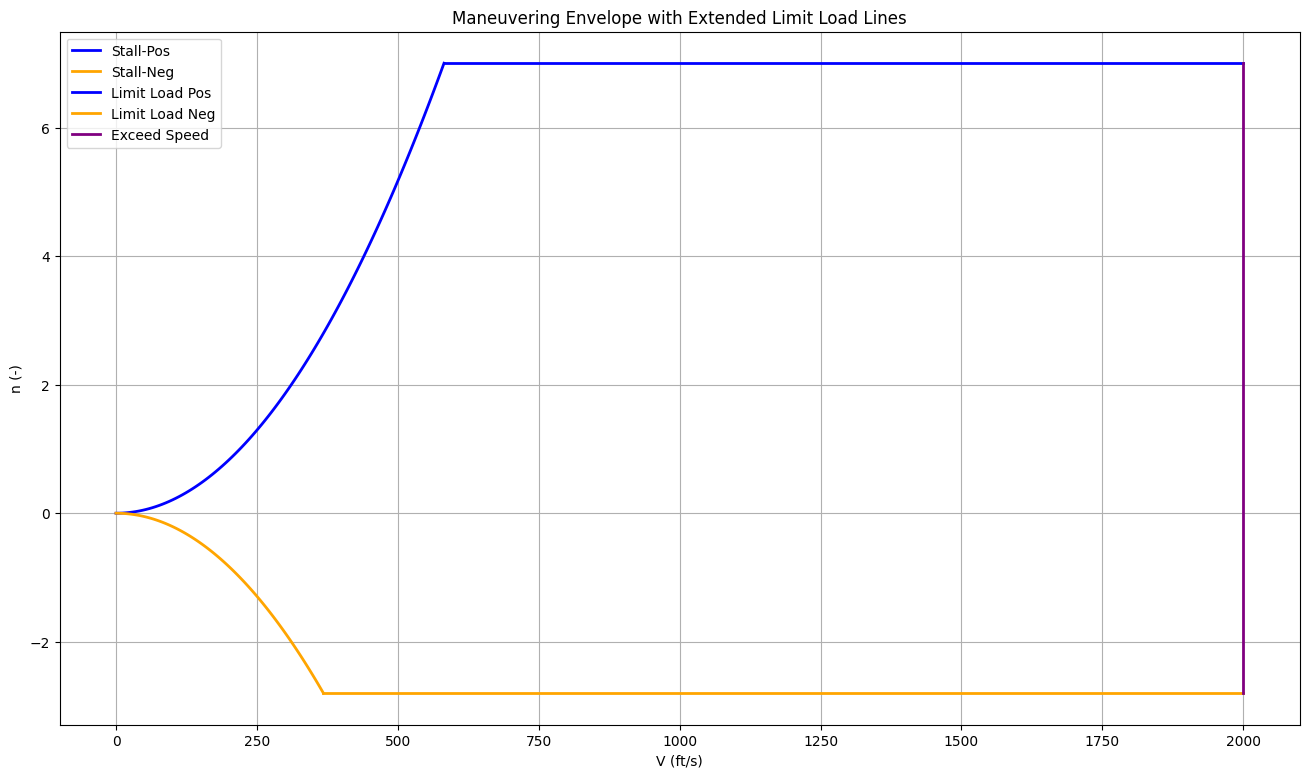

In [8]:
# lastly, we can also plot the exceed speed lines
V_exceed = V_max 
# vertical line goes from negative limit load to positive limit load
n_exceed_line = np.linspace(n_neg_limit[0], n_pos_limit[0], 100)
V_exceed_line = V_exceed * np.ones_like(n_exceed_line)


plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope with Extended Limit Load Lines')
plt.xlabel("V (ft/s)")
plt.ylabel("n (-)")
plt.plot(V_stall_pos, n_stall_pos_intersection  , label='Stall-Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_stall_neg, n_stall_neg_intersection  , label='Stall-Neg', linewidth=2, marker=None, markersize=8, color ='orange')
plt.plot(V_pos_limit_extended, n_pos_extended, label='Limit Load Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_neg_limit_extended, n_neg_extended, label='Limit Load Neg', linewidth=2, marker=None, markersize=8, color = 'orange')
plt.plot(V_exceed_line, n_exceed_line,label='Exceed Speed', linewidth=2, color='purple')
plt.grid(True)
plt.legend(loc='best')
plt.show()